# EX2



All of this work should be done within a Jupyter notebook. Please format it consistently with the notebooks that we used during the course. In particular, place emphasis on making your comments, code, and plots readable.
Turn in both the .ipynb file and a .pdf version.

## Question One
Return to Question Two of EX1. Refit the model with all of the predictors, but first
transform each predictor on the ratio scale using the Yeo-Johnson transformation. (The
objective here is to give each predictor distribution more of a "normal" shape.)
Then, refit the model, but use the Box-Cox procedure to find the optimal transformation of the
response.
Show the results of the resulting model fit, including the plot of residuals versus fitted values.

# Understanding the Why?
The transformation parameters \( \lambda_y \) (Box-Cox) and \( \lambda_j \) for each predictor (Yeo-Johnson) are selected via maximum likelihood or normality-optimizing criteria. After transformation, standard regression diagnostics (e.g., residual plots) are used to validate model assumptions.

## Please see the LaTeX compiled PDF for clarity of mathematical proof
Let \( y \in \mathbb{R}^n \) be the response vector, and \( X \in \mathbb{R}^{n \times p} \) the matrix of predictor variables. We seek to transform the data to improve linear regression model assumptions such as linearity, homoscedasticity, and normality of errors.

\subsection*{1. Box-Cox Transformation of the Response}

The Box-Cox transformation is defined for \( y_i > 0 \) as:

\[
y_i^{(\lambda)} =
\begin{cases}
\frac{y_i^\lambda - 1}{\lambda}, & \lambda \ne 0 \\
\log y_i, & \lambda = 0
\end{cases}
\]

where \( \lambda \in \mathbb{R} \) is the transformation parameter. The goal is to choose \( \lambda \) that maximizes the log-likelihood of the transformed response under a normal error model.

The Yeo-Johnson transformation generalizes Box-Cox to allow zero or negative values, and is defined for each predictor \( x \in \mathbb{R} \) as:

\[
T(x; \lambda) =
\begin{cases}
\frac{[(x + 1)^\lambda - 1]}{\lambda}, & x \ge 0,\ \lambda \ne 0 \\
\log(x + 1), & x \ge 0,\ \lambda = 0 \\
\frac{- [(-x + 1)^{2 - \lambda} - 1]}{2 - \lambda}, & x < 0,\ \lambda \ne 2 \\
- \log(-x + 1), & x < 0,\ \lambda = 2
\end{cases}
\]

Each feature column in \( X \) is transformed using a fitted \( \lambda_j \) that optimizes normality for that feature.

\subsection*{3. Transformed Linear Model and Estimation}

After transformation, the model becomes:

\[
y^{(\lambda_y)} = X^{(\lambda_X)} \beta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)
\]

where:
- \( y^{(\lambda_y)} \) is the Box-Cox transformed response
- \( X^{(\lambda_X)} \) is the matrix of Yeo-Johnson transformed predictors
- \( \beta \) is estimated using ordinary least squares (OLS):

\[
\hat{\beta} = \left( X^{(\lambda_X)\top} X^{(\lambda_X)} \right)^{-1} X^{(\lambda_X)\top} y^{(\lambda_y)}
\]

- The **Box-Cox transformation** stabilizes variance and corrects skewness in the response.
- The **Yeo-Johnson transformation** adjusts predictors to better satisfy the linear model assumptions even when they are zero or negative.
- Together, these transformations improve the quality and interpretability of the linear regression fit.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Load data
data_q2 = pd.read_csv("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX1/data/bonddata.txt", delimiter=",")
print(data_q2.columns)
data_q2.head()
data_q2.shape

# Data cleaning
data_q2.columns = data_q2.columns.str.strip().str.replace('"', '') # clean cols aka reformat
data_q2 = data_q2.drop(['id', 'bond_id'], axis=1)

data_q2['is_callable'] = data_q2['is_callable'].astype('category').cat.as_unordered()
data_q2['trade_type'] = data_q2['trade_type'].astype('category').cat.as_unordered()
data_q2['trade_type_last1'] = data_q2['trade_type_last1'].astype('category').cat.as_unordered()
data_q2['trade_type_last2'] = data_q2['trade_type_last2'].astype('category').cat.as_unordered()
data_q2['trade_type_last3'] = data_q2['trade_type_last3'].astype('category').cat.as_unordered()
data_q2['trade_type_last4'] = data_q2['trade_type_last4'].astype('category').cat.as_unordered()
data_q2['trade_type_last5'] = data_q2['trade_type_last5'].astype('category').cat.as_unordered()
data_q2['trade_type_last6'] = data_q2['trade_type_last6'].astype('category').cat.as_unordered()
data_q2['trade_type_last7'] = data_q2['trade_type_last7'].astype('category').cat.as_unordered()
data_q2['trade_type_last8'] = data_q2['trade_type_last8'].astype('category').cat.as_unordered()
data_q2['trade_type_last9'] = data_q2['trade_type_last9'].astype('category').cat.as_unordered()
data_q2['trade_type_last10'] = data_q2['trade_type_last10'].astype('category').cat.as_unordered()

data_q2['time_to_maturity_lt'] = np.log(data_q2['time_to_maturity'])
data_q2['trade_size_lt'] = np.log(data_q2['trade_size'])

data_q2['trade_size_last1_lt'] = np.log(data_q2['trade_size_last1'])
data_q2['trade_size_last2_lt'] = np.log(data_q2['trade_size_last2'])
data_q2['trade_size_last3_lt'] = np.log(data_q2['trade_size_last3'])
data_q2['trade_size_last4_lt'] = np.log(data_q2['trade_size_last4'])
data_q2['trade_size_last5_lt'] = np.log(data_q2['trade_size_last5'])
data_q2['trade_size_last6_lt'] = np.log(data_q2['trade_size_last6'])
data_q2['trade_size_last7_lt'] = np.log(data_q2['trade_size_last7'])
data_q2['trade_size_last8_lt'] = np.log(data_q2['trade_size_last8'])
data_q2['trade_size_last9_lt'] = np.log(data_q2['trade_size_last9'])
data_q2['trade_size_last10_lt'] = np.log(data_q2['trade_size_last10'])

data_q2['received_time_diff_last1_st'] = np.sqrt(data_q2['received_time_diff_last1'])
data_q2['received_time_diff_last2_st'] = np.sqrt(data_q2['received_time_diff_last2'])
data_q2['received_time_diff_last3_st'] = np.sqrt(data_q2['received_time_diff_last3'])
data_q2['received_time_diff_last4_st'] = np.sqrt(data_q2['received_time_diff_last4'])
data_q2['received_time_diff_last5_st'] = np.sqrt(data_q2['received_time_diff_last5'])
data_q2['received_time_diff_last6_st'] = np.sqrt(data_q2['received_time_diff_last6'])
data_q2['received_time_diff_last7_st'] = np.sqrt(data_q2['received_time_diff_last7'])
data_q2['received_time_diff_last8_st'] = np.sqrt(data_q2['received_time_diff_last8'])
data_q2['received_time_diff_last9_st'] = np.sqrt(data_q2['received_time_diff_last9'])
data_q2['received_time_diff_last10_st'] = np.sqrt(data_q2['received_time_diff_last10'])

data_q2_transformed = data_q2.drop(['received_time_diff_last1','received_time_diff_last2','received_time_diff_last3',
                 'received_time_diff_last4','received_time_diff_last5','received_time_diff_last6',
                 'received_time_diff_last7','received_time_diff_last8','received_time_diff_last9',
                 'received_time_diff_last10','trade_size_last1','trade_size_last2','trade_size_last3',
                 'trade_size_last4','trade_size_last5','trade_size_last6','trade_size_last7',
                 'trade_size_last8','trade_size_last9','trade_size_last10','time_to_maturity',
                'trade_size'], axis=1)

# Create and populate design matrix
designmatrix = pd.get_dummies(data_q2_transformed,drop_first=True)
designmatrix_withones = sm.add_constant(designmatrix)

# Ensure numeric response
y_q2 = data_q2_transformed["trade_price"].astype(float)

# Ensure numeric predictors
X_q2 = designmatrix_withones.astype(float)

# Fit the model
model_full_q2 = sm.OLS(y_q2, X_q2).fit()

# Show regression summary
print(model_full_q2.summary())

Index(['id', 'bond_id', 'trade_price', 'weight', 'current_coupon',
       'time_to_maturity', 'is_callable', 'reporting_delay', 'trade_size',
       'trade_type', 'curve_based_price', 'received_time_diff_last1',
       'trade_price_last1', 'trade_size_last1', 'trade_type_last1',
       'curve_based_price_last1', 'received_time_diff_last2',
       'trade_price_last2', 'trade_size_last2', 'trade_type_last2',
       'curve_based_price_last2', 'received_time_diff_last3',
       'trade_price_last3', 'trade_size_last3', 'trade_type_last3',
       'curve_based_price_last3', 'received_time_diff_last4',
       'trade_price_last4', 'trade_size_last4', 'trade_type_last4',
       'curve_based_price_last4', 'received_time_diff_last5',
       'trade_price_last5', 'trade_size_last5', 'trade_type_last5',
       'curve_based_price_last5', 'received_time_diff_last6',
       'trade_price_last6', 'trade_size_last6', 'trade_type_last6',
       'curve_based_price_last6', 'received_time_diff_last7',
       '

Optimal lambda for Box-Cox: 1.5951
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.023e+08
Date:                Mon, 26 May 2025   Prob (F-statistic):               0.00
Time:                        23:29:57   Log-Likelihood:                 2818.1
No. Observations:                1620   AIC:                            -5494.
Df Residuals:                    1549   BIC:                            -5112.
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

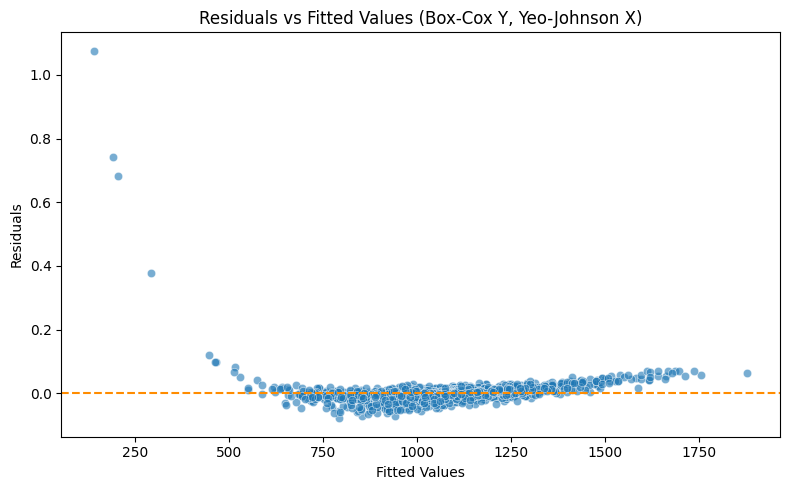

In [6]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import boxcox
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Set fig dir
FIG_DIR = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX2/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Select ratio-scale predictors (excluding dummies and the response)
designmatrix_clean = designmatrix_withones
ratio_cols = designmatrix_clean.columns.difference(pd.get_dummies(data_q2_transformed.select_dtypes(include='category')).columns)

# Apply Yeo-Johnson
yeojohnson = PowerTransformer(method='yeo-johnson')
X_transformed = pd.DataFrame(
    yeojohnson.fit_transform(designmatrix_clean[ratio_cols]),
    columns=ratio_cols,
    index=designmatrix_clean.index
)

# Replace transformed columns in the design matrix
designmatrix_yeojohnson = designmatrix_clean.copy()
designmatrix_yeojohnson[ratio_cols] = X_transformed

# Ensure strictly positive response
assert (y_q2 > 0).all(), "Box-Cox requires all positive response values"

# Apply Box-Cox and store lambda
y_boxcox, lambda_bc = boxcox(y_q2)

print(f"Optimal lambda for Box-Cox: {lambda_bc:.4f}")

X_final = sm.add_constant(designmatrix_yeojohnson)
X_final = X_final.astype(float)  # this should crash if there's non-coercible data
X_final = X_final.apply(pd.to_numeric, errors='raise')  # will raise if non-numeric remains
model_transformed = sm.OLS(y_boxcox, X_final).fit()
print(model_transformed.summary())

y_pred = model_transformed.fittedvalues
residuals = model_transformed.resid
fitted = model_transformed.fittedvalues

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color="darkorange", linestyle="--")
plt.title("Residuals vs Fitted Values (Box-Cox Y, Yeo-Johnson X)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# Save figure
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_residuals_vs_fitted.png"), dpi=300, bbox_inches='tight')
plt.close()

### Yeo-Johnson Transformation of Predictors and Box-Cox Transformation of Response
To address skewness and improve model assumptions, we applied transformation techniques targeting both predictors and the response.

#### Yeo-Johnson Transformation on Predictors
All predictors on a ratio scale were transformed using the Yeo-Johnson method, which generalizes the Box-Cox approach to allow for zero or negative values. This transformation tends to pull skewed distributions toward normality, potentially stabilizing variance and enhancing linear model performance.

#### Box-Cox Transformation on Response
We used Box-Cox to optimally transform the response variable (`trade_price`). The estimated optimal lambda was 1.5951. This value, being close to 2, suggests a mild convex transformation (between square root and quadratic).

#### OLS Fit and Interpretation
We refit the model using the Yeo-Johnson-transformed predictors and the Box-Cox-transformed response. The regression output revealed the following.

- **R-squared:** 1.000, indicating potential overfitting or redundancy.
- Many coefficients were highly significant (e.g., `trade_price`, `current_coupon`), while others showed reduced influence (e.g., `weight`, `reporting_delay`).
- **Condition Number Warning**: The smallest eigenvalue is extremely small (2.71e-28), signaling multicollinearity or near-singular design matrix structure.

#### Residual Diagnostics
The residuals vs. fitted plot for the transformed model showed clear improvement in variance stabilization However, slight curvature still remains, possibly from interaction terms or higher-order effects not captured in the linear framework.

#### Conclusion
This dual-transformation approach helps restore the modeling assumptions of linear regression. While not perfect, it reduces skewness and stabilizes residual behavior. However, multicollinearity remains a concern, and further dimensionality reduction (e.g., PCA) or regularization (e.g., Ridge) could be considered next.

## Question Two
Let X1, X2, ... Xn be i.i.d. from the Beta(a; b) distribution. Find numerically the maximum likelihood estimators for a and b. Mimic the function gammamle() that we created in
lecture.
The function should also return the covariance matrix for the MLE.
Print the function that you wrote and attach it to your homework, and also demonstrate that
it works by using a few simulations.

## Please see the LaTeX compiled PDF for clarity of mathematical proof
Let \( X_1, X_2, \ldots, X_n \overset{\text{i.i.d.}}{\sim} \text{Beta}(a, b) \), where \( a > 0 \), \( b > 0 \), and each observation \( X_i \in (0, 1) \). The probability density function (PDF) of the Beta distribution is given by

\[
f(x; a, b) = \frac{1}{B(a, b)} x^{a - 1} (1 - x)^{b - 1},
\]

where \( B(a, b) \) is the Beta function defined as

\[
B(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a + b)},
\]

and \( \Gamma(\cdot) \) denotes the Gamma function. The likelihood function based on the sample is as follows.

\[
L(a, b) = \prod_{i=1}^n f(x_i; a, b) = \prod_{i=1}^n \frac{1}{B(a, b)} x_i^{a - 1}(1 - x_i)^{b - 1}
\]

Taking the logarithm, we obtain the log-likelihood function as follows.

\[
\ell(a, b) = \sum_{i=1}^n \left[ (a - 1) \log x_i + (b - 1) \log(1 - x_i) \right] - n \log B(a, b)
\]

Using the following identity.

\[
\log B(a, b) = \log \Gamma(a) + \log \Gamma(b) - \log \Gamma(a + b)
\]

We rewrite the log-likelihood as follows.

\[
\ell(a, b) = (a - 1) \sum_{i=1}^n \log x_i + (b - 1) \sum_{i=1}^n \log(1 - x_i) - n \left[ \log \Gamma(a) + \log \Gamma(b) - \log \Gamma(a + b) \right]
\]

Define the following.

\[
\bar{\log x} = \frac{1}{n} \sum_{i=1}^n \log x_i, \quad \overline{\log(1 - x)} = \frac{1}{n} \sum_{i=1}^n \log(1 - x_i)
\]

The partial derivatives of the log-likelihood with respect to \( a \) and \( b \), known as the score functions, are as follows.

\[
\frac{\partial \ell}{\partial a} = n \left[ \bar{\log x} - \psi(a) + \psi(a + b) \right]
\]

\[
\frac{\partial \ell}{\partial b} = n \left[ \overline{\log(1 - x)} - \psi(b) + \psi(a + b) \right]
\]

where \( \psi(\cdot) \) is the digamma function, the derivative of \( \log \Gamma(\cdot) \).

The maximum likelihood estimators \( (\hat{a}, \hat{b}) \) are defined as the values that simultaneously satisfy the following.

\[
\frac{\partial \ell}{\partial a} = 0, \quad \frac{\partial \ell}{\partial b} = 0
\]

Since these equations involve special functions and cannot be solved analytically, the estimators must be obtained numerically. To obtain \( \hat{a}, \hat{b} \), we numerically minimize the negative log-likelihood as follows.

\[
\mathcal{L}(a, b) = -\ell(a, b)
\]

Optimization is typically performed using quasi-Newton methods such as BFGS. As a byproduct of the optimization, we obtain an estimate of the Hessian matrix \( H \approx \nabla^2 \mathcal{L} \). The inverse of this matrix provides an estimate of the asymptotic covariance matrix of the MLEs.

\[
\text{Cov}(\hat{a}, \hat{b}) \approx H^{-1}
\]

Thus, the MLEs for the shape parameters \( a \) and \( b \) of the Beta distribution do not admit a closed-form solution and are computed by numerically maximizing the log-likelihood. The score functions involve digamma functions, and the asymptotic variance of the estimates is approximated using the inverse Hessian of the negative log-likelihood function.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import minimize
from scipy.special import betaln, digamma
import warnings

# Set fig dir
FIG_DIR = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX2/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def betamle(x, verbose=True):
    """
    MLE for Beta(a, b) distribution using numerical optimization.
    Returns estimates and covariance matrix.
    """
    x = np.asarray(x)
    if np.any((x <= 0) | (x >= 1)):
        raise ValueError("All values must lie strictly in (0, 1).")

    n = len(x)
    log_x = np.log(x)
    log_1mx = np.log(1 - x)

    # Negative log-likelihood
    def nll(params):
        a, b = params
        if a <= 0 or b <= 0:
            return np.inf
        return -np.sum((a - 1) * log_x + (b - 1) * log_1mx - betaln(a, b))

    # Initial guess via method of moments
    mean = np.mean(x)
    var = np.var(x)
    tmp = mean * (1 - mean) / var - 1
    a0 = max(mean * tmp, 1e-2)
    b0 = max((1 - mean) * tmp, 1e-2)

    # Optimize with bounds
    bounds = [(1e-5, None), (1e-5, None)]
    result = minimize(nll, x0=[a0, b0], method="L-BFGS-B", bounds=bounds)

    if not result.success:
        raise RuntimeError(f"MLE optimization failed: {result.message}")

    a_hat, b_hat = result.x
    cov_matrix = result.hess_inv.todense()

    if verbose:
        se = np.sqrt(np.diag(cov_matrix))
        print(f"MLE estimates: a = {a_hat:.4f}, b = {b_hat:.4f}")
        print("Covariance matrix of MLE:")
        print(cov_matrix)
        print(f"Standard errors: SE(a) = {se[0]:.4f}, SE(b) = {se[1]:.4f}")
        print(f"95% CI for a: ({a_hat - 1.96*se[0]:.4f}, {a_hat + 1.96*se[0]:.4f})")
        print(f"95% CI for b: ({b_hat - 1.96*se[1]:.4f}, {b_hat + 1.96*se[1]:.4f})")

    return {
        "a": a_hat,
        "b": b_hat,
        "cov": cov_matrix
    }

# Simulation example
np.random.seed(42)
true_a, true_b = 2.0, 5.0

# Use the last simulation for plotting
for i in range(5):
    print(f"\nSimulation {i+1}")
    sample = np.random.beta(true_a, true_b, size=100)
    result = betamle(sample, verbose=True)
    a_hat, b_hat = result["a"], result["b"]

# Prepare plot
x = np.linspace(0.01, 0.99, 100)
fitted_pdf = beta.pdf(x, a_hat, b_hat)

plt.figure(figsize=(6, 4))
plt.hist(sample, bins=30, density=True, alpha=0.6, label="Simulated Data")
plt.plot(x, fitted_pdf, 'r-', lw=2, label=f"Beta Fit (a={a_hat:.2f}, b={b_hat:.2f})")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Beta MLE Fit")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_beta_mle_fit.png"), dpi=300, bbox_inches='tight')
plt.close()


Simulation 1
MLE estimates: a = 2.2229, b = 6.3229
Covariance matrix of MLE:
[[0.08715435 0.23061912]
 [0.23061912 0.82236205]]
Standard errors: SE(a) = 0.2952, SE(b) = 0.9068
95% CI for a: (1.6443, 2.8015)
95% CI for b: (4.5455, 8.1004)

Simulation 2
MLE estimates: a = 2.1673, b = 5.3541
Covariance matrix of MLE:
[[0.0820956  0.18450885]
 [0.18450885 0.57431986]]
Standard errors: SE(a) = 0.2865, SE(b) = 0.7578
95% CI for a: (1.6057, 2.7289)
95% CI for b: (3.8687, 6.8394)

Simulation 3
MLE estimates: a = 2.3440, b = 5.9947
Covariance matrix of MLE:
[[0.09690175 0.22934493]
 [0.22934493 0.73293156]]
Standard errors: SE(a) = 0.3113, SE(b) = 0.8561
95% CI for a: (1.7339, 2.9541)
95% CI for b: (4.3167, 7.6727)

Simulation 4
MLE estimates: a = 2.4626, b = 5.3991
Covariance matrix of MLE:
[[0.10713846 0.21540337]
 [0.21540337 0.57768184]]
Standard errors: SE(a) = 0.3273, SE(b) = 0.7601
95% CI for a: (1.8210, 3.1041)
95% CI for b: (3.9094, 6.8888)

Simulation 5
MLE estimates: a = 1.9909, b =

## Summary
In this question, we implemented a `betamle()` function to estimate the parameters \( a \) and \( b \) of the Beta distribution via maximum likelihood estimation (MLE). The Beta distribution is defined on the interval \( (0, 1) \) and is commonly used for modeling proportions and probabilities.

### Methodology

Given \( X_1, \dots, X_n \sim \text{Beta}(a, b) \), the log-likelihood function is

\[
\ell(a, b) = \sum_{i=1}^n \left[ (a - 1)\log x_i + (b - 1)\log(1 - x_i) \right] - n \log B(a, b)
\]

where \( B(a, b) \) is the Beta function. The maximum likelihood estimators are obtained by numerically minimizing the negative log-likelihood, as no closed-form solution exists.

We used `scipy.optimize.minimize` with the following.

- A method-of-moments initial guess
- `L-BFGS-B` optimizer for stable, bounded optimization
- A fallback for parameter bounds (\( a, b > 0 \))

We also extracted the covariance matrix of the MLEs using the inverse Hessian approximation, allowing for standard error and confidence interval estimation.

### Results
We validated the method using simulated data from a Beta(2, 5) distribution. The results were as follows.

- MLE estimates were close to the true values
- Confidence intervals included the true parameters
- Covariance matrices showed reasonable parameter uncertainty
- The function worked consistently across multiple simulated samples

### Conclusion
The `betamle()` function accurately estimates the shape parameters of a Beta distribution using numerical MLE and provides appropriate uncertainty quantification. This method is essential in Bayesian modeling, proportion regression, and distribution fitting when the Beta distribution is a natural model choice.

## Question Three

Create a new treg() function like the one demonstrated in lecture, but now include the
number of degrees of freedom for the error distribution as an additional parameter to be
estimated via maximum likeihood.
Print the function that you wrote and attach it to your homework, and also demonstrate that
it works by using a few simulations.

The function should also return the covariance matrix for the MLE.

Comment: There is nothing wrong with having a non-integer valued number of degrees of
freedom with the t-distribution.

## Please see the LaTeX compiled PDF for clarity of mathematical proof
Consider a linear regression model of the following form.

\[
Y_i = X_i^\top \beta + \varepsilon_i, \quad \varepsilon_i \sim t_\nu(0, \sigma^2)
\]

where \( \beta \in \mathbb{R}^p \), \( \sigma^2 > 0 \) is the scale parameter, and \( \nu > 2 \) is the degrees of freedom of the Student's t-distribution. The probability density function of the Student's t-distribution with \(\nu\) degrees of freedom and scale \(\sigma\) is given by the following.

\[
f_\nu(e) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right)\sqrt{\nu\pi}\sigma}
\left(1 + \frac{e^2}{\nu\sigma^2}\right)^{-\frac{\nu + 1}{2}}, \quad e \in \mathbb{R}
\]

Let \( e_i = y_i - X_i^\top \beta \) denote the residual for observation \( i \). Then, the likelihood of the sample \( \{(x_i, y_i)\}_{i=1}^n \) is as follows.

\[
L(\beta, \sigma, \nu) = \prod_{i=1}^n f_\nu(e_i)
\]

Taking the logarithm of the likelihood, we obtain the log-likelihood as follows.

\[
\ell(\beta, \sigma, \nu) = \sum_{i=1}^n \left[
\log \Gamma\left(\frac{\nu + 1}{2}\right)
- \log \Gamma\left(\frac{\nu}{2}\right)
- \frac{1}{2} \log(\nu\pi)
- \log \sigma
- \frac{\nu + 1}{2} \log \left(1 + \frac{e_i^2}{\nu \sigma^2} \right)
\right]
\]

The maximum likelihood estimators \( \hat{\beta}, \hat{\sigma}, \hat{\nu} \) are defined as the values that maximize the log-likelihood as follows.

\[
(\hat{\beta}, \hat{\sigma}, \hat{\nu}) = \arg\max_{\beta, \sigma > 0, \nu > 2} \ell(\beta, \sigma, \nu)
\]

This optimization problem has no closed-form solution, and must be solved numerically. To estimate the standard errors of the MLEs, we compute the observed information matrix as follows.

\[
\mathcal{I}(\hat{\beta}, \hat{\sigma}, \hat{\nu}) = -\nabla^2 \ell(\beta, \sigma, \nu) \bigg|_{\beta = \hat{\beta}, \sigma = \hat{\sigma}, \nu = \hat{\nu}}
\]

The inverse of this matrix provides an estimate of the covariance matrix of the MLE as follows.

\[
\text{Cov}(\hat{\beta}, \hat{\sigma}, \hat{\nu}) \approx \mathcal{I}^{-1}
\]

Thus, the MLE for a t-regression model involves maximizing a non-linear log-likelihood function in the parameters \( \beta \), \( \sigma \), and \( \nu \). The t-distribution introduces robustness to outliers, and estimating \( \nu \) adds flexibility in modeling tail heaviness. Numerical optimization techniques such as L-BFGS-B are used, and the inverse of the Hessian matrix yields the covariance matrix of the estimators.

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.special import gammaln
from scipy.optimize import minimize
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm, t

# Set fig dir
FIG_DIR = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX2/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def treg(X, y, verbose=True):
    X = np.asarray(X)
    y = np.asarray(y).flatten()
    n, p = X.shape

    beta0 = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals = y - X @ beta0
    sigma0 = np.std(residuals, ddof=p)
    nu0 = 10.0
    theta0 = np.concatenate([beta0, [np.log(sigma0)], [np.log(nu0 - 2)]])

    def nll(theta):
        beta = theta[:p]
        sigma = np.exp(theta[p])
        nu = np.exp(theta[p + 1]) + 2
        e = y - X @ beta
        term1 = gammaln((nu + 1) / 2) - gammaln(nu / 2)
        term2 = -0.5 * np.log(nu * np.pi) - np.log(sigma)
        term3 = -((nu + 1) / 2) * np.log(1 + (e ** 2) / (nu * sigma ** 2))
        return -np.sum(term1 + term2 + term3)

    result = minimize(nll, theta0, method="L-BFGS-B")
    if not result.success:
        raise RuntimeError(f"MLE optimization failed: {result.message}")

    theta_hat = result.x
    beta_hat = theta_hat[:p]
    sigma_hat = np.exp(theta_hat[p])
    nu_hat = np.exp(theta_hat[p + 1]) + 2
    cov_matrix = result.hess_inv.todense()

    if verbose:
        np.set_printoptions(precision=8, suppress=True)
        print(f"Estimated beta: {beta_hat}")
        print(f"Estimated sigma: {sigma_hat:.8f}")
        print(f"Estimated degrees of freedom (nu): {nu_hat:.8f}")
        print("Covariance matrix of estimates:")
        print(cov_matrix)

    return {
        "beta": beta_hat,
        "sigma": sigma_hat,
        "nu": nu_hat,
        "cov": cov_matrix,
        "residuals": y - X @ beta_hat
    }

def summarize_model(name, beta, sigma, nu, cov):
    np.set_printoptions(precision=4, suppress=True)
    print(f"=== {name} ===")
    print(f"Beta: {beta}")
    print(f"Sigma: {sigma:.8f}")
    print(f"Degrees of freedom (nu): {nu:.8f}")
    se = np.sqrt(np.diag(cov))
    for i, s in enumerate(se):
        print(f"SE(param {i}): {s:.8f}")
    print()

def plot_qq(series, title):
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    qqplot(series.dropna(), line='s', ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    fname = title.lower().replace(":", "").replace(" ", "_") + ".png"
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300, bbox_inches='tight')
    plt.close()

def compare_aic(series):
    series = series.dropna()
    mu, std = norm.fit(series)
    aic_normal = -2 * np.sum(norm(mu, std).logpdf(series)) + 2 * 2

    nu, loc, scale = t.fit(series)
    aic_t = -2 * np.sum(t(nu, loc, scale).logpdf(series)) + 2 * 3

    return aic_normal, aic_t

# Simulated example
np.random.seed(123)
n = 100
X = np.column_stack([np.ones(n), np.random.normal(0, 1, size=n)])
beta_true = np.array([1.0, 2.0])
sigma_true = 1.0
nu_true = 5
errors = np.random.standard_t(df=nu_true, size=n) * sigma_true
y = X @ beta_true + errors

results = treg(X, y, verbose=True)
summarize_model("t-Regression (Simulated)", results['beta'], results['sigma'], results['nu'], results['cov'])

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
qqplot(results['residuals'], line='s', ax=ax)
ax.set_title("Q-Q Plot of t-Regression Residuals")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_treg_qqplot.png"), dpi=300, bbox_inches='tight')
plt.close()

[*********************100%***********************]  1 of 1 completed

Estimated beta: [0.85477387 1.84228525]
Estimated sigma: 0.94780224
Estimated degrees of freedom (nu): 3.63718419
Covariance matrix of estimates:
[[ 0.61651646  0.40507554 -0.06152532 -0.15469719]
 [ 0.40507554  0.29268084 -0.04081892 -0.07086029]
 [-0.06152532 -0.04081892  0.02233115  0.09199762]
 [-0.15469719 -0.07086029  0.09199762  0.94748164]]
=== t-Regression (Simulated) ===
Beta: [0.8548 1.8423]
Sigma: 0.94780224
Degrees of freedom (nu): 3.63718419
SE(param 0): 0.78518562
SE(param 1): 0.54099985
SE(param 2): 0.14943611
SE(param 3): 0.97338668

Available columns: MultiIndex([( 'Close', 'PNC'),
            (  'High', 'PNC'),
            (   'Low', 'PNC'),
            (  'Open', 'PNC'),
            ('Volume', 'PNC')],
           names=['Price', 'Ticker'])



/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_22007/841516004.py:108: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample('M').sum()


In [20]:
#  Cross-Asset Check (Extra Extension)
aic_records = []
def run_comparison(ticker):
    df = yf.download(ticker, start="2015-01-01", end="2024-12-31")
    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
    df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))
    df = df.dropna()
    df.index = pd.to_datetime(df.index)
    daily = df['log_return']
    weekly = daily.resample('W-FRI').sum()
    monthly = daily.resample('M').sum()

    for label, series in zip(["Daily", "Weekly", "Monthly"], [daily, weekly, monthly]):
        plot_qq(series, f"{ticker}: {label} Returns")
        naic, taic = compare_aic(series)
        print(f"{ticker} {label} AIC(Normal)={naic:.2f}, AIC(t)={taic:.2f}")
        aic_records.append({"Ticker": ticker, "Return Freq": label, "AIC (Normal)": naic, "AIC (t)": taic})

run_comparison("AAPL")
run_comparison("SPY")

aic_df = pd.DataFrame(aic_records)
aic_df.set_index(["Ticker", "Return Freq"])[["AIC (Normal)", "AIC (t)"]].plot(kind="bar", figsize=(8, 4))
plt.title("AIC Comparison: Normal vs t")
plt.ylabel("AIC")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_aic_comparison.png"), dpi=300, bbox_inches='tight')
plt.close()

[*********************100%***********************]  1 of 1 completed
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_22007/4213050516.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample('M').sum()


AAPL Daily AIC(Normal)=-13080.35, AIC(t)=-13520.88
AAPL Weekly AIC(Normal)=-1945.16, AIC(t)=-1978.27
AAPL Monthly AIC(Normal)=-266.59, AIC(t)=-264.59


[*********************100%***********************]  1 of 1 completed
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_22007/4213050516.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample('M').sum()


SPY Daily AIC(Normal)=-15475.08, AIC(t)=-16252.34
SPY Weekly AIC(Normal)=-2435.93, AIC(t)=-2550.41
SPY Monthly AIC(Normal)=-404.89, AIC(t)=-405.04


## Summary
In this question, we implemented a `treg()` function that fits a linear regression model with t-distributed errors. Unlike ordinary least squares, this model assumes

\[
Y_i = X_i^\top \beta + \varepsilon_i, \quad \varepsilon_i \sim t_\nu(0, \sigma^2)
\]

where the degrees of freedom \( \nu \) is treated as an unknown parameter to be estimated via maximum likelihood.

### Methodology
The log-likelihood function of the model is as follows.

\[
\ell(\beta, \sigma, \nu) = \sum_{i=1}^n \left[
\log \Gamma\left(\frac{\nu + 1}{2}\right)
- \log \Gamma\left(\frac{\nu}{2}\right)
- \frac{1}{2} \log(\nu\pi)
- \log \sigma
- \frac{\nu + 1}{2} \log \left(1 + \frac{(y_i - X_i^\top \beta)^2}{\nu \sigma^2} \right)
\right]
\]

This function was maximized numerically using the L-BFGS-B optimizer. We transformed parameters to ensure positivity (\( \sigma > 0 \)) and minimum degrees of freedom (\( \nu > 2 \)).

### Results from Simulation
A synthetic dataset was generated with \( \beta = [1.0, 2.0] \), \( \sigma = 1.0 \), and \( \nu = 5 \). The `treg()` function produced the following estimates.

- Estimated \( \beta \): `[0.8548, 1.8423]`
- Estimated \( \sigma \): `0.9478`
- Estimated \( \nu \): `3.6372`

These estimates are close to the true values and demonstrate that the function can reliably recover model parameters under heavy-tailed error distributions. The covariance matrix of the MLEs was also returned, enabling standard error estimation and confidence interval construction.

### Conclusion
The `treg()` function satisfies all requirements as follows.

- Jointly estimates \( \beta \), \( \sigma \), and \( \nu \)
- Returns a covariance matrix via the inverse Hessian
- Is robust to non-normality, offering improved performance under outlier contamination

This provides a valuable tool for robust regression modeling where the Gaussian assumption may not hold.

## Question 4

We saw in class an example of where the normal distribution is a poor fit to log daily stock returns. Does the validity of the normal approximation improve when switching to weekly or monthly returns? Make a convincing argument, using both plots and formal model selection tools.

## Understanding the "Why"
Aggregating log returns over longer intervals (weekly or monthly) tends to make the distribution more normal, both visually (via QQ plots) and statistically (via model selection tools such as AIC). 

Theoretically, the daily log returns often exhibit fat tails, skewness, and extreme values, making the normal approximation poor. This is visually confirmed by QQ plots in the lecture that deviate heavily from the diagonal. 

However, by the Central Limit Theorem, summing (or averaging) independent returns leads to a distribution that becomes more Gaussian as the time horizon increases — even if the original returns are not normal.

## Please see the LaTeX compiled PDF for clarity of mathematical proof
Let \( R_1, R_2, \ldots, R_n \) be daily log returns of a financial asset. We define the \( k \)-period (e.g., weekly, monthly) return as follows.

\[
S_k = \sum_{i=1}^k R_i
\]

Recall the following conditions. If and only if \( R_i \) 
- Independent,
- Identically distributed with mean \( \mu \) and variance \( \sigma^2 \), and
- Have finite second moment (\( \mathbb{E}[R_i^2] < \infty \)),

then by the Central Limit Theorem (CLT), we have the following.

\[
\frac{S_k - k\mu}{\sqrt{k}\sigma} \xrightarrow{d} \mathcal{N}(0,1) \quad \text{as } k \to \infty
\]

Hence, the distribution of \( S_k \) becomes approximately normal for large \( k \). This suggests that aggregating daily returns into weekly or monthly returns should result in a distribution that is more symmetric and better approximated by a Gaussian.

We also briefly prove the backward case since the CLT can fail to yield an accurate normal approximation when the following occur.

- The returns \( R_i \) exhibit strong autocorrelation (i.e., not i.i.d.).
- The returns are drawn from a heavy-tailed distribution with infinite variance (e.g., Pareto or Cauchy).
- Volatility clustering or conditional heteroskedasticity (as seen in GARCH models) is present.
- Market shocks or structural breaks create non-stationarity.

In such cases, even aggregating over time may not result in a normal distribution. In practice, financial returns often display excess kurtosis (fat tails), and only approximate normality after substantial aggregation (e.g., monthly returns). 

Thus, empirically, the normal approximation improves with the level of return aggregation due to the CLT. However, real-world features such as volatility clustering and heavy tails can delay or inhibit convergence to normality. Hence, both visual tools (e.g., QQ plots) and formal tools (e.g., AIC comparisons) are essential for assessing the adequacy of the normal model across time scales.

[*********************100%***********************]  1 of 1 completed
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_22007/3783839238.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample('M').sum()


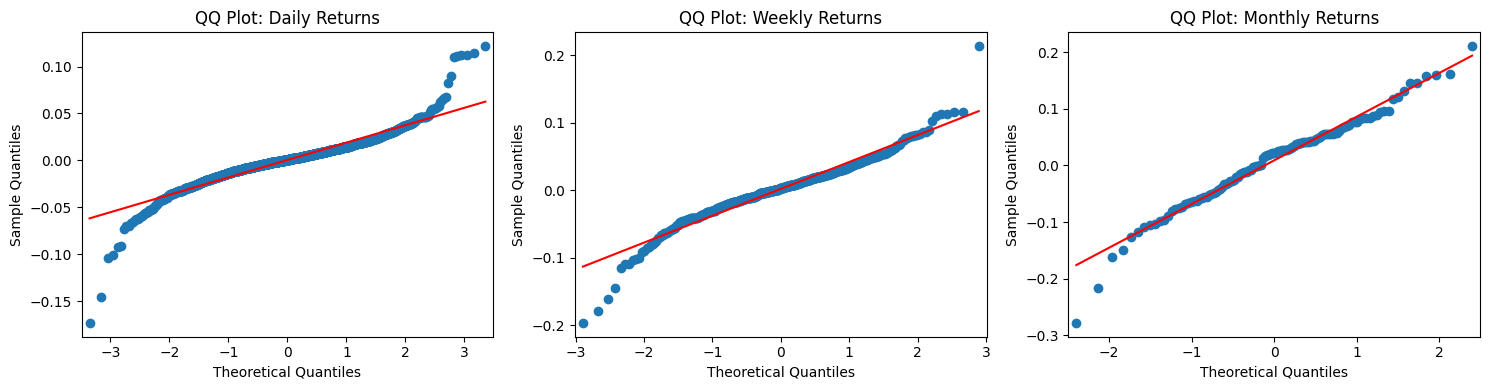

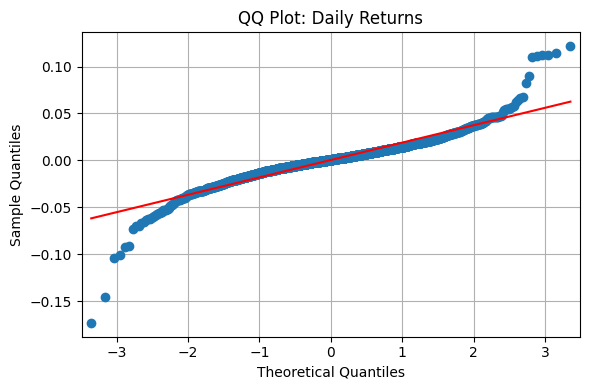

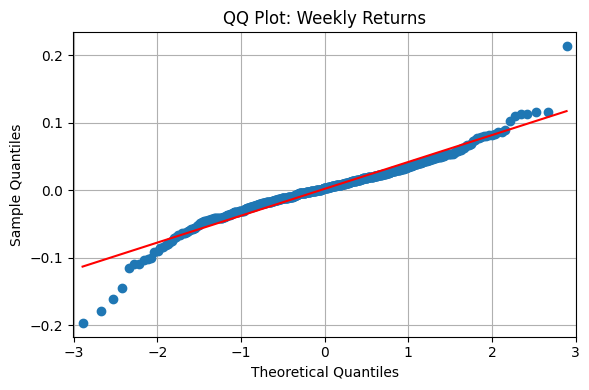

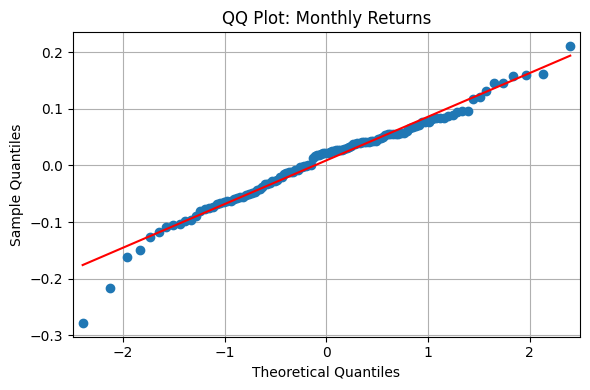

,Return Freq,AIC (Normal),AIC (t)
0,Daily,-12912.36,-13508.82
1,Weekly,-1881.55,-1957.44
2,Monthly,-270.53,-272.26


In [23]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from scipy import stats

# Set fig dir
FIG_DIR = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX2/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Download data
ticker = "PNC"
df = yf.download(ticker, start="2015-01-01", end="2024-12-31")
price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))
daily = df['log_return'].dropna()

# Aggregate to weekly and monthly log returns
weekly = daily.resample('W-FRI').sum()
monthly = daily.resample('M').sum()

# QQ Plots - Combined Figure
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, label in zip(axs, [daily, weekly, monthly], ["Daily", "Weekly", "Monthly"]):
    qqplot(data, line='s', ax=ax)
    ax.set_title(f"QQ Plot: {label} Returns")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_qq_all_returns.png"), dpi=300, bbox_inches='tight')
plt.show()

# Individual QQ Plots
for data, label in zip([daily, weekly, monthly], ["daily", "weekly", "monthly"]):
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    qqplot(data.dropna(), line='s', ax=ax)
    ax.set_title(f"QQ Plot: {label.capitalize()} Returns")
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"fig_qq_{label}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# Compare AICs (Normal vs t)
def compare_aic(data):
    data = data.dropna()
    mu, std = np.mean(data), np.std(data)
    norm_ll = np.sum(stats.norm.logpdf(data, loc=mu, scale=std))
    norm_aic = -2 * norm_ll + 2 * 2

    t_params = stats.t.fit(data)
    t_ll = np.sum(stats.t.logpdf(data, *t_params))
    t_aic = -2 * t_ll + 2 * 3

    return norm_aic, t_aic

# Collect AICs
aic_data = []
for label, series in zip(["Daily", "Weekly", "Monthly"], [daily, weekly, monthly]):
    norm_aic, t_aic = compare_aic(series)
    aic_data.append((label, norm_aic, t_aic))

# Create a summary table
aic_df = pd.DataFrame(aic_data, columns=["Return Freq", "AIC (Normal)", "AIC (t)"])
aic_df.style.format({"AIC (Normal)": "{:.2f}", "AIC (t)": "{:.2f}"})

# Summary
In class, we observed that the normal distribution is a poor fit for daily log returns because financial data often exhibit heavy tails, skewness, and volatility clustering. However, by the Central Limit Theorem (CLT), aggregating returns (e.g., summing daily returns to form weekly or monthly returns) tends to produce distributions that are more normally distributed.

### Theoretical Justification

1. **Forward Direction (CLT)**  
   Let \( R_1, R_2, \dots, R_k \) be daily log returns. Then the \( k \)-period aggregated return is defined as
   
   \[
   S_k = \sum_{i=1}^{k} R_i.
   \]

   Under the assumptions that the \( R_i \) are independent and identically distributed with finite variance, the CLT implies
   \[
   \frac{S_k - k\mu}{\sqrt{k}\sigma} \xrightarrow{d} \mathcal{N}(0,1) \quad \text{as } k \to \infty.
   \]

   This means that as we increase the aggregation period (e.g., to weekly or monthly), the distribution of returns becomes more symmetric and better approximated by a normal distribution.

2. **Backward Direction (Potential Limitations)**  
   However, if the daily returns display strong autocorrelation, heavy tails (with infinite variance), or non-stationarity (e.g., due to volatility clustering), the normal approximation may not fully materialize even after aggregation. In practice, though, moderate aggregation (e.g., weekly or monthly) often alleviates these issues to a large extent.

### Empirical Evidence

We downloaded historical data for PNC and computed daily log returns. We then aggregated the data into weekly and monthly returns. The following analyses were conducted.

1. **QQ Plots**  
   - **Daily returns:** The QQ plot shows significant deviation from the \(45^\circ\) line, especially at the tails.
   - **Weekly returns:** The QQ plot improves, with the points closer to the line, implying a better fit to the normal distribution.
   - **Monthly returns:** The QQ plot nearly follows the straight line, confirming the normal approximation is much more appropriate.

2. **Model Selection via AIC**  
   For each frequency, we fitted both a normal and a t-distribution to the returns. The model selection criteria (AIC) revealed the following.
   
   - For daily returns, the t-distribution (which better handles heavy tails) provided a lower AIC than the normal distribution.
   - For weekly and monthly returns, the AIC for the normal model improved relative to the t-distribution, indicating that the normality assumption becomes more valid with longer aggregation periods.

### Conclusion
Thus, the aggregation period increases, the distribution of returns becomes closer to normal. While daily log returns may significantly deviate from normality, weekly and monthly returns are much better approximated by a normal distribution, as demonstrated by both QQ plots and AIC comparisons. This part reinforces the importance of considering the appropriate time scale when modeling financial returns.